In [16]:
import os
import yaml
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

# Class Distribution analysis

In [17]:
dataset_path = 'bdd100k--1'
train_labels_path = os.path.join(dataset_path, 'train', 'labels')
val_labels_path = os.path.join(dataset_path, 'valid', 'labels')


In [18]:
with open(os.path.join(dataset_path, 'data.yaml'), 'r') as f:
    data = yaml.safe_load(f)
    class_names = data['names']

In [19]:
class_names

['bike', 'bus', 'car', 'motor', 'person', 'rider', 'truck']

In [20]:
def count_classes(directory):
    counter = Counter()

    files = [f for f in os.listdir(directory) if f.endswith('.txt')]

    for file in files:
        file_path = os.path.join(directory, file)
        try:
            with open(file_path, 'r') as f:
                lines = f.readlines()
                
            for line in lines:
                parts = line.strip().split()
                if len(parts)>= 5:
                    class_id = int(parts[0])
                    counter[class_id] += 1
        except Exception as e:
            print(f"Error processing {file_path}: {e}")
    return counter

In [21]:
train_counter = count_classes(train_labels_path)
val_counter = count_classes(val_labels_path)

total_counter = train_counter + val_counter
class_counts = {class_names[class_id]: count for class_id, count in total_counter.items()}

sorted_counts = dict(sorted(class_counts.items(), key=lambda x: x[1], reverse=True))

In [22]:
for class_name, count in sorted_counts.items():
    print(f"{class_name}: {count}")

car: 91111
person: 11809
truck: 3775
bus: 1427
bike: 912
rider: 581
motor: 407


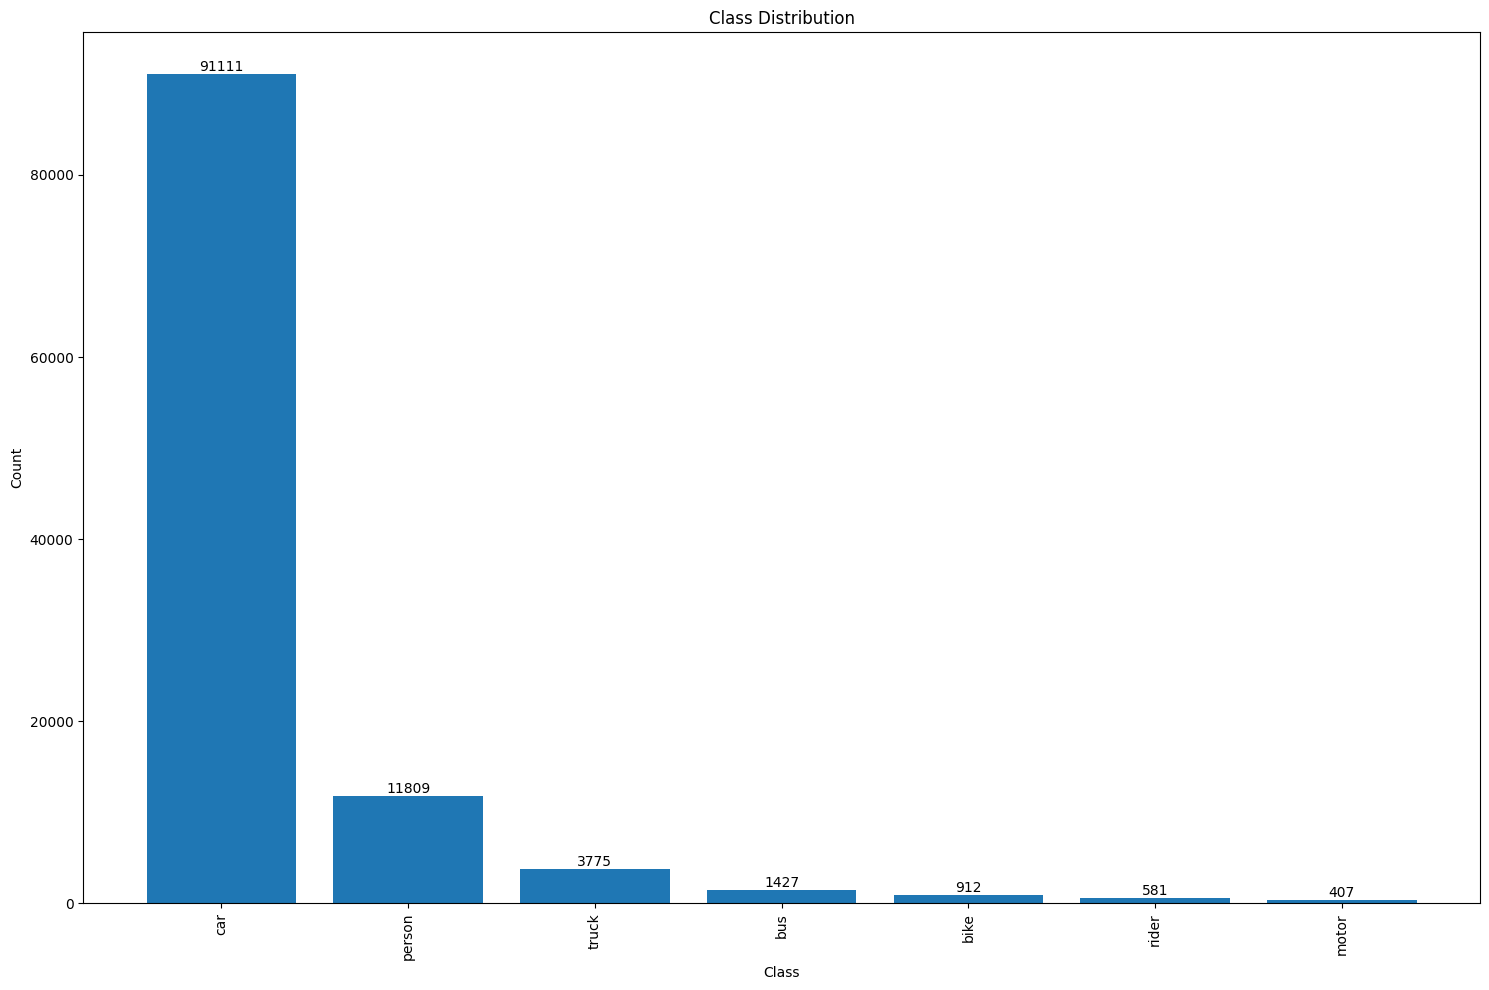

In [23]:
plt.figure(figsize=(15, 10))
bars = plt.bar(sorted_counts.keys(), sorted_counts.values())

plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, int(height), ha='center', va='bottom')

plt.show()


# Analysis of the classes

In [33]:
import yaml
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
from torchvision import models, transforms
from sklearn.manifold import TSNE
from PIL import Image
import torch.nn as nn
import supervision as sv
import seaborn as sns

In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

device

device(type='cuda')

In [35]:
model = models.efficientnet_b0(weights='DEFAULT')
model.classifier = nn.Identity()
model = model.to(device)
model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [36]:
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [37]:
dataset_path = 'bdd100k--1'
with open(os.path.join(dataset_path, 'data.yaml')) as f:
    data = yaml.load(f, Loader=yaml.FullLoader)
    class_names = data['names']

In [38]:
def extract_features(img, xyxy):
    x1, y1, x2, y2 = map(int, xyxy)
    if x2 <= x1 or y2 <= y1 or x1 < 0 or y1 < 0:
        return None
    
    h, w = img.shape[:2]
    x1, y1, x2, y2 = max(0, x1), max(0, y1), min(w, x2), min(h, y2)
    
    crop = img[y1:y2, x1:x2]
    if crop.size == 0 or crop.shape[0] < 5 or crop.shape[1] < 5:
        return None

    crop_pil = Image.fromarray(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))

    crop_tensor = preprocess(crop_pil).unsqueeze(0).to(device)

    with torch.no_grad():
        features = model(crop_tensor)
        
    return features.cpu().numpy().flatten()

In [39]:
def collect_features(split_dir, max_samples_per_class=50):
    features_list = []
    labels_list = []
    class_counters = {i: 0 for i in range(len(class_names))}
    
    dataset_directory = os.path.join(dataset_path, split_dir)
    
    dataset = sv.DetectionDataset.from_yolo(
        images_directory_path=os.path.join(dataset_directory, 'images'),
        annotations_directory_path=os.path.join(dataset_directory, 'labels'),
        data_yaml_path=os.path.join(dataset_path, 'data.yaml')
    )
    
    # En la nueva API, las anotaciones se devuelven como un objeto Detections
    for image_path, image, detections in tqdm(dataset, desc=f"Processing {split_dir}"):
        img = image
        if img is None:
            continue
            
        # En la nueva API, detections tiene propiedades como .class_id que son arrays
        if len(detections) == 0:  # Si no hay detecciones, continuar
            continue
            
        # Obtener los class_ids y las bounding boxes
        class_ids = detections.class_id  # Esto es un array de todos los class_ids
        xyxys = detections.xyxy  # Esto es un array de todas las bounding boxes
        
        # Procesar cada detección
        for idx, (class_id, xyxy) in enumerate(zip(class_ids, xyxys)):
            # Limitar muestras por clase
            if class_counters[class_id] >= max_samples_per_class:
                continue
                
            # Extraer el crop de la imagen
            x1, y1, x2, y2 = map(int, xyxy)
            crop = img[y1:y2, x1:x2]
            
            # Verificar que el crop es válido
            if crop.size == 0:
                continue
                
            # Convertir a PIL para procesamiento
            crop_pil = Image.fromarray(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
            crop_tensor = preprocess(crop_pil).unsqueeze(0).to(device)
            
            # Extraer características con el modelo
            with torch.no_grad():
                features = model(crop_tensor).squeeze().cpu().numpy()
            
            features_list.append(features)
            labels_list.append(class_id)
            class_counters[class_id] += 1
    
    # Informar sobre las muestras recolectadas
    print(f"Muestras recolectadas por clase en {split_dir}:")
    for class_id, count in class_counters.items():
        if count > 0:
            print(f"  {class_names[class_id]}: {count} muestras")
    
    return np.array(features_list), np.array(labels_list)

In [43]:
print('Feature extraction initialized')
train_features, train_labels = collect_features('train')
val_features, val_labels = collect_features('valid')

train_features, val_features

Feature extraction initialized


Processing train: 100%|██████████| 6857/6857 [00:10<00:00, 667.28it/s]


Muestras recolectadas por clase en train:
  bike: 50 muestras
  bus: 50 muestras
  car: 50 muestras
  motor: 50 muestras
  person: 50 muestras
  rider: 50 muestras
  truck: 50 muestras


Processing valid: 100%|██████████| 1960/1960 [00:05<00:00, 366.73it/s]

Muestras recolectadas por clase en valid:
  bike: 50 muestras
  bus: 50 muestras
  car: 50 muestras
  motor: 50 muestras
  person: 50 muestras
  rider: 50 muestras
  truck: 50 muestras


(array([[-1.9282450e-01, -2.3828585e-01, -1.3078232e-01, ...,
         -2.3597473e-01, -1.5977791e-01, -2.3422921e-04],
        [-1.5297067e-01, -2.0821381e-01, -1.4012082e-01, ...,
         -2.1431763e-01, -1.5745077e-01,  1.7083828e-01],
        [-2.0396058e-01, -1.4287946e-01, -1.4952035e-01, ...,
         -1.3555244e-01, -1.0961994e-01,  4.3381664e-01],
        ...,
        [-4.8360288e-02, -8.5857801e-02, -1.7654456e-01, ...,
         -1.0238656e-01,  1.3728584e-01, -1.5865697e-01],
        [ 5.9284592e-01, -8.1781529e-02, -1.0667044e-01, ...,
         -1.1365981e-01, -4.3334778e-02, -1.8892533e-01],
        [-7.6921009e-03, -7.3074698e-02, -5.6075882e-02, ...,
         -1.7564414e-01,  3.9361244e-01,  6.5221876e-01]], dtype=float32),
 array([[-0.20992225, -0.1234431 , -0.06759609, ..., -0.19635649,
         -0.21329173, -0.1755225 ],
        [-0.19075389, -0.13542613, -0.0741427 , ..., -0.16502953,
         -0.13192023, -0.13077767],
        [-0.14668311, -0.07178932, -0.04207251

In [44]:
len(train_features) == 0 and len(val_features) == 0

False

In [45]:
features = np.vstack([train_features, val_features])
labels = np.concatenate([train_labels, val_labels])

In [46]:
len(features), features.shape[1]

(700, 1280)

In [47]:
print("Applying t-sne")
perplexity_value = min(30, len(features) - 1)

tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity_value)
features_2d = tsne.fit_transform(features)

Applying t-sne


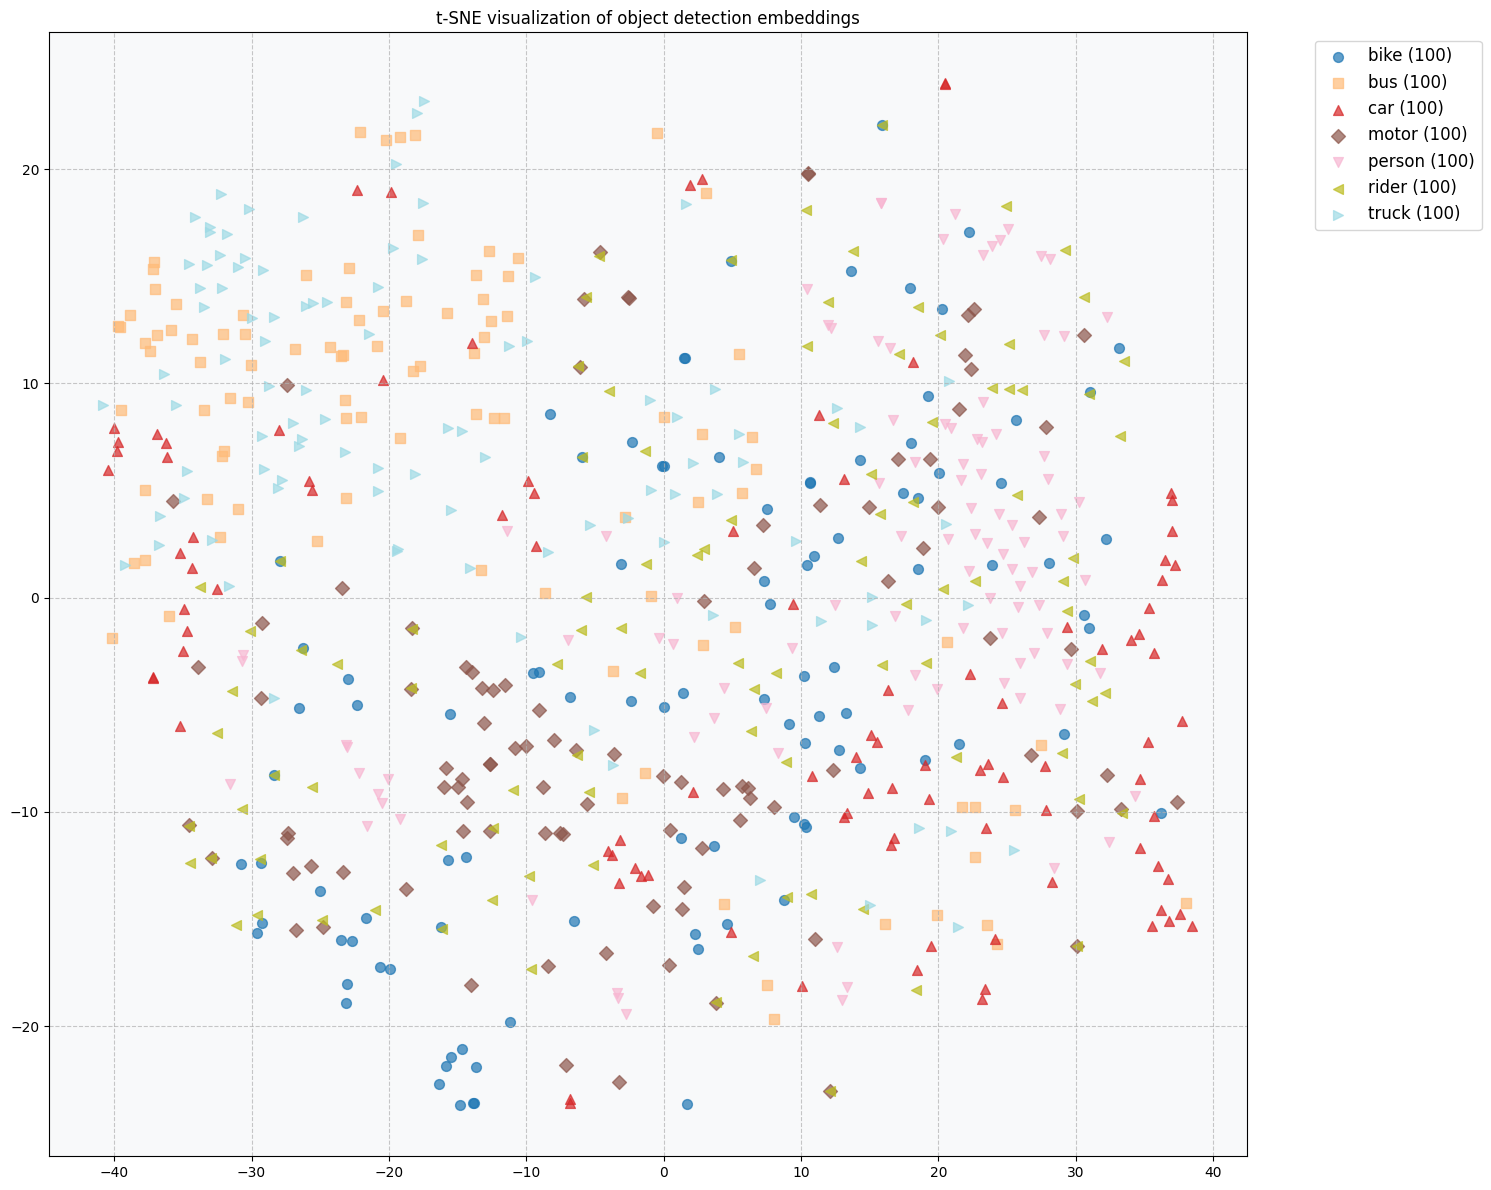

In [48]:
plt.figure(figsize=(15, 12))

unique_labels = sorted(set(labels))
num_classes = len(unique_labels)
colors = plt.cm.tab20(np.linspace(0, 1, min(num_classes, 20)))

if num_classes > 20:
    additional_colors = plt.cm.tab20(np.linspace(0, 1, num_classes - 20))
    colors = np.vstack([colors, additional_colors])

markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']

for i, class_id in enumerate(unique_labels):
    mask = labels == class_id
    marker = markers[i % len(markers)]
    plt.scatter(
            features_2d[mask, 0], features_2d[mask, 1],
            color=colors[i % len(colors)],
            marker=marker,
            label=f"{class_names[class_id]} ({np.sum(mask)})",
            alpha=0.7,
            s=50
        )

plt.title("t-SNE visualization of object detection embeddings")

if len(unique_labels) > 15:
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=10)
else:
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)

plt.tight_layout()

plt.grid(True, linestyle='--', alpha=0.7)

plt.gca().set_facecolor('#f8f9fa')
plt.savefig('tsne_features.png', dpi=300, bbox_inches='tight')
plt.show()

Distance between bike and bus: 19.59
Distance between bike and car: 5.45
Distance between bike and motor: 2.90
Distance between bike and person: 13.92
Distance between bike and rider: 4.02
Distance between bike and truck: 20.07
Distance between bus and car: 23.68
Distance between bus and motor: 17.48
Distance between bus and person: 29.53
Distance between bus and rider: 20.23
Distance between bus and truck: 0.87
Distance between car and motor: 8.35
Distance between car and person: 8.63
Distance between car and rider: 3.52
Distance between car and truck: 24.02
Distance between motor and person: 16.72
Distance between motor and rider: 6.38
Distance between motor and truck: 18.03
Distance between person and rider: 10.60
Distance between person and truck: 29.66
Distance between rider and truck: 20.55
Closest pair: bus and truck
Farthest pair: person and truck


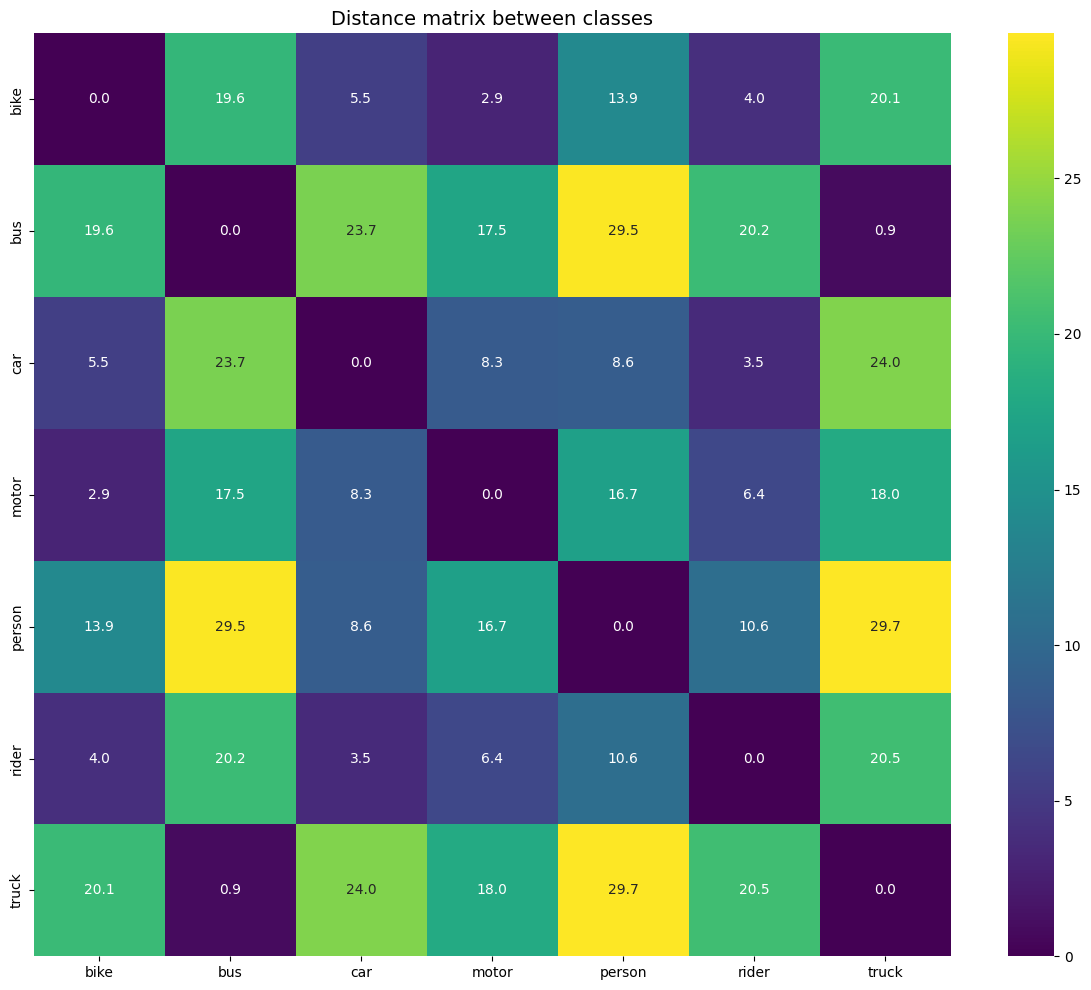

In [49]:
if len(unique_labels) > 1:
    class_centers = {}
    for class_id in unique_labels:
        mask = labels == class_id
        class_centers[class_id] = np.mean(features_2d[mask], axis=0)

    distance_matrix = np.zeros((len(unique_labels), len(unique_labels)))
    for i, c1 in enumerate(unique_labels):
        for j, c2 in enumerate(unique_labels):
            if i < j:
                distance = np.linalg.norm(class_centers[c1] - class_centers[c2])
                distance_matrix[i, j] = distance
                distance_matrix[j, i] = distance
                print(f"Distance between {class_names[c1]} and {class_names[c2]}: {distance:.2f}")

    non_zero_indices = np.where(distance_matrix > 0)
    min_idx = np.argmin(distance_matrix[non_zero_indices])
    min_i, min_j = non_zero_indices[0][min_idx], non_zero_indices[1][min_idx]
    closest_pair = (unique_labels[min_i], unique_labels[min_j])
    print(f"Closest pair: {class_names[closest_pair[0]]} and {class_names[closest_pair[1]]}")

    max_idx = np.argmax(distance_matrix)
    max_i, max_j = max_idx // len(unique_labels), max_idx % len(unique_labels)
    farthest_pair = (unique_labels[max_i], unique_labels[max_j])
    print(f"Farthest pair: {class_names[farthest_pair[0]]} and {class_names[farthest_pair[1]]}")

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        distance_matrix,
        xticklabels=[class_names[id] for id in unique_labels],
        yticklabels=[class_names[id] for id in unique_labels],
        annot=True,
        cmap='viridis',
        fmt='.1f'
    )
    plt.title('Distance matrix between classes', fontsize=14)
    plt.tight_layout()
    plt.savefig('distance_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

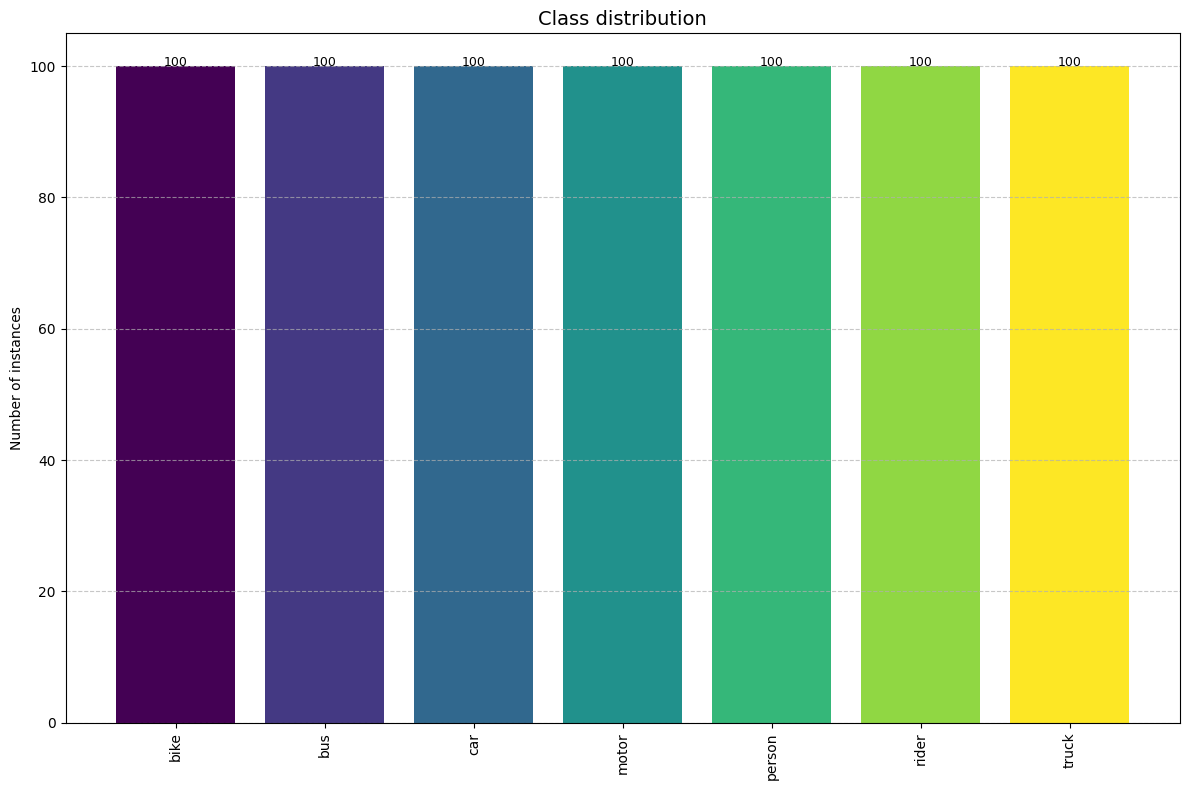

In [50]:
if features.shape[0] > 1:
    class_counts = {}
    for class_id in np.unique(labels):
        class_counts[class_names[class_id]] = np.sum(labels == class_id)

    sorted_counts = {k: v for k, v in sorted(class_counts.items(), key=lambda item: item[1], reverse=True)}
    
    plt.figure(figsize=(12, 8))
    
    bars = plt.bar(
        sorted_counts.keys(),
        sorted_counts.values(),
        color=plt.cm.viridis(np.linspace(0, 1, len(sorted_counts)))
    )
    
    plt.title('Class distribution', fontsize=14)
    plt.xticks(rotation=90)
    plt.ylabel('Number of instances')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2.,
            height + 0.1,
            f'{int(height)}',
            ha='center',
            fontsize=9
        )
    
    plt.tight_layout()
    plt.savefig('class_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

# Spacial distribution with heatmap

In [51]:
import os
import yaml
import cv2
import numpy as np
import matplotlib.pyplot as plt
import supervision as sv
from tqdm import tqdm
import seaborn as sns
from collections import defaultdict

In [52]:
dataset_path = 'bdd100k--1'
with open(os.path.join(dataset_path, 'data.yaml'), 'r') as f:
    data = yaml.safe_load(f)
    class_names = data['names']

In [55]:
def analyze_spatial_distribution(split_dirs=['train', 'valid']):
    # Para almacenar las coordenadas normalizadas de los centros
    class_centers = defaultdict(list)
    
    # Para almacenar tamaños relativos
    class_sizes = defaultdict(list)
    
    # Iteramos por cada split (train/val)
    for split_dir in split_dirs:
        dataset_directory = os.path.join(dataset_path, split_dir)
        
        # Cargar el dataset usando supervision
        dataset = sv.DetectionDataset.from_yolo(
            images_directory_path=os.path.join(dataset_directory, 'images'),
            annotations_directory_path=os.path.join(dataset_directory, 'labels'),
            data_yaml_path=os.path.join(dataset_path, 'data.yaml')
        )
        
        print(f"Analizando distribución espacial en {split_dir}...")
        
        # Nuevo método de iteración recomendado por Supervision
        for image_path, img, detections in tqdm(dataset, desc=f"Processing {split_dir}"):
            if img is None:
                continue
                
            img_height, img_width = img.shape[:2]
            
            # Si no hay detecciones, continuar
            if len(detections) == 0:
                continue
                
            # Obtener los class_ids y las bounding boxes
            class_ids = detections.class_id
            xyxys = detections.xyxy
            
            # Procesar cada detección
            for class_id, xyxy in zip(class_ids, xyxys):
                x1, y1, x2, y2 = xyxy
                
                # Calcular centro y normalizar (entre 0 y 1)
                center_x = (x1 + x2) / (2 * img_width)
                center_y = (y1 + y2) / (2 * img_height)
                
                # Calcular tamaño relativo (área del bbox / área de la imagen)
                rel_width = (x2 - x1) / img_width
                rel_height = (y2 - y1) / img_height
                rel_size = rel_width * rel_height
                
                # Almacenar coordenadas del centro y tamaño
                class_centers[class_id].append((center_x, center_y))
                class_sizes[class_id].append(rel_size)
    
    # Filtrar clases con suficientes muestras para visualización (mínimo 10)
    valid_classes = {class_id: centers for class_id, centers in class_centers.items() 
                     if len(centers) >= 10}
    
    if not valid_classes:
        print("No hay suficientes muestras para crear mapas de calor.")
        return
    
    # Configurar visualización
    n_classes = len(valid_classes)
    
    # Determinar número de filas y columnas para subplots
    n_cols = min(3, n_classes)
    n_rows = (n_classes + n_cols - 1) // n_cols
    
    # Crear figura para mapas de calor individuales
    plt.figure(figsize=(n_cols * 6, n_rows * 5))
    
    # Para cada clase, generar un mapa de calor
    for i, (class_id, centers) in enumerate(valid_classes.items()):
        centers = np.array(centers)
        
        # Crear subplot
        plt.subplot(n_rows, n_cols, i + 1)
        
        # Generar mapa de calor usando KDE (Kernel Density Estimation)
        if len(centers) >= 20:  # Necesitamos suficientes puntos para KDE
            sns.kdeplot(
                x=centers[:, 0], 
                y=centers[:, 1],
                cmap="rocket_r", 
                fill=True,
                thresh=0.05,
                levels=15,
                alpha=0.8
            )
        
        # Sobreponer scatter plot con transparencia
        sns.scatterplot(
            x=centers[:, 0], 
            y=centers[:, 1],
            alpha=0.3, 
            s=np.array(class_sizes[class_id]) * 1000,  # Tamaño proporcional al area relativa
            color='white',
            edgecolor='black',
            linewidth=0.5
        )
        
        plt.xlim(0, 1)
        plt.ylim(0, 1)
        plt.gca().invert_yaxis()  # Invertir eje Y para coincidir con coordenadas de imagen
        
        # Añadir cuadrícula para referencia
        plt.grid(linestyle='--', alpha=0.4)
        
        # Añadir líneas centrales
        plt.axhline(0.5, color='gray', linestyle='--', alpha=0.3)
        plt.axvline(0.5, color='gray', linestyle='--', alpha=0.3)
        
        plt.title(f"{class_names[class_id]} (n={len(centers)})")
        plt.xlabel("Posición X normalizada")
        plt.ylabel("Posición Y normalizada")
    
    plt.tight_layout()
    plt.savefig('spatial_distribution_heatmaps.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Crear un único mapa de calor combinado con todas las clases
    plt.figure(figsize=(12, 10))
    
    # Seleccionar top 10 clases más frecuentes si hay más de 10
    top_classes = sorted(valid_classes.items(), key=lambda x: len(x[1]), reverse=True)[:10]
    
    # Diferentes marcadores para cada clase
    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']
    
    # Graficar cada clase con un color diferente
    for i, (class_id, centers) in enumerate(top_classes):
        centers = np.array(centers)
        sizes = np.array(class_sizes[class_id]) * 500  # Escalar tamaños
        
        plt.scatter(
            centers[:, 0], 
            centers[:, 1], 
            alpha=0.5, 
            s=sizes,
            marker=markers[i % len(markers)],
            label=f"{class_names[class_id]} (n={len(centers)})"
        )
    
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.gca().invert_yaxis()  # Invertir eje Y para coincidir con coordenadas de imagen
    
    # Añadir cuadrícula y líneas de referencia
    plt.grid(linestyle='--', alpha=0.4)
    plt.axhline(0.5, color='black', linestyle='--', alpha=0.5)
    plt.axvline(0.5, color='black', linestyle='--', alpha=0.5)
    
    # Añadir esquema de la imagen
    plt.plot([0, 1, 1, 0, 0], [0, 0, 1, 1, 0], 'k-', alpha=0.8)
    
    plt.title("Distribución espacial de objetos por clase", fontsize=16)
    plt.xlabel("Posición X normalizada", fontsize=12)
    plt.ylabel("Posición Y normalizada", fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.savefig('combined_spatial_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Análisis de sesgo posicional
    print("\nAnálisis de sesgo posicional:")
    
    for class_id, centers in valid_classes.items():
        centers = np.array(centers)
        mean_x = centers[:, 0].mean()
        mean_y = centers[:, 1].mean()
        std_x = centers[:, 0].std()
        std_y = centers[:, 1].std()
        
        # Calcular distancia desde el centro de la imagen
        dist_from_center = np.sqrt((mean_x - 0.5)**2 + (mean_y - 0.5)**2)
        
        # Determinar si hay un posible sesgo posicional
        bias_level = "Alto" if dist_from_center > 0.25 else "Medio" if dist_from_center > 0.15 else "Bajo"
        
        print(f"{class_names[class_id]}:")
        print(f"  Posición media: X={mean_x:.3f}, Y={mean_y:.3f}")
        print(f"  Variabilidad: σx={std_x:.3f}, σy={std_y:.3f}")
        print(f"  Distancia desde el centro: {dist_from_center:.3f}")
        print(f"  Posible sesgo posicional: {bias_level}")
        
        # Identificar cuadrante preferido
        quadrant = ""
        if mean_y < 0.5:
            if mean_x < 0.5:
                quadrant = "superior izquierdo"
            else:
                quadrant = "superior derecho"
        else:
            if mean_x < 0.5:
                quadrant = "inferior izquierdo"
            else:
                quadrant = "inferior derecho"
        
        print(f"  Cuadrante preferido: {quadrant}")
        print()


Analizando distribución espacial en train...


Processing train: 100%|██████████| 6857/6857 [00:07<00:00, 884.76it/s]


Analizando distribución espacial en valid...


Processing valid: 100%|██████████| 1960/1960 [00:02<00:00, 835.55it/s]


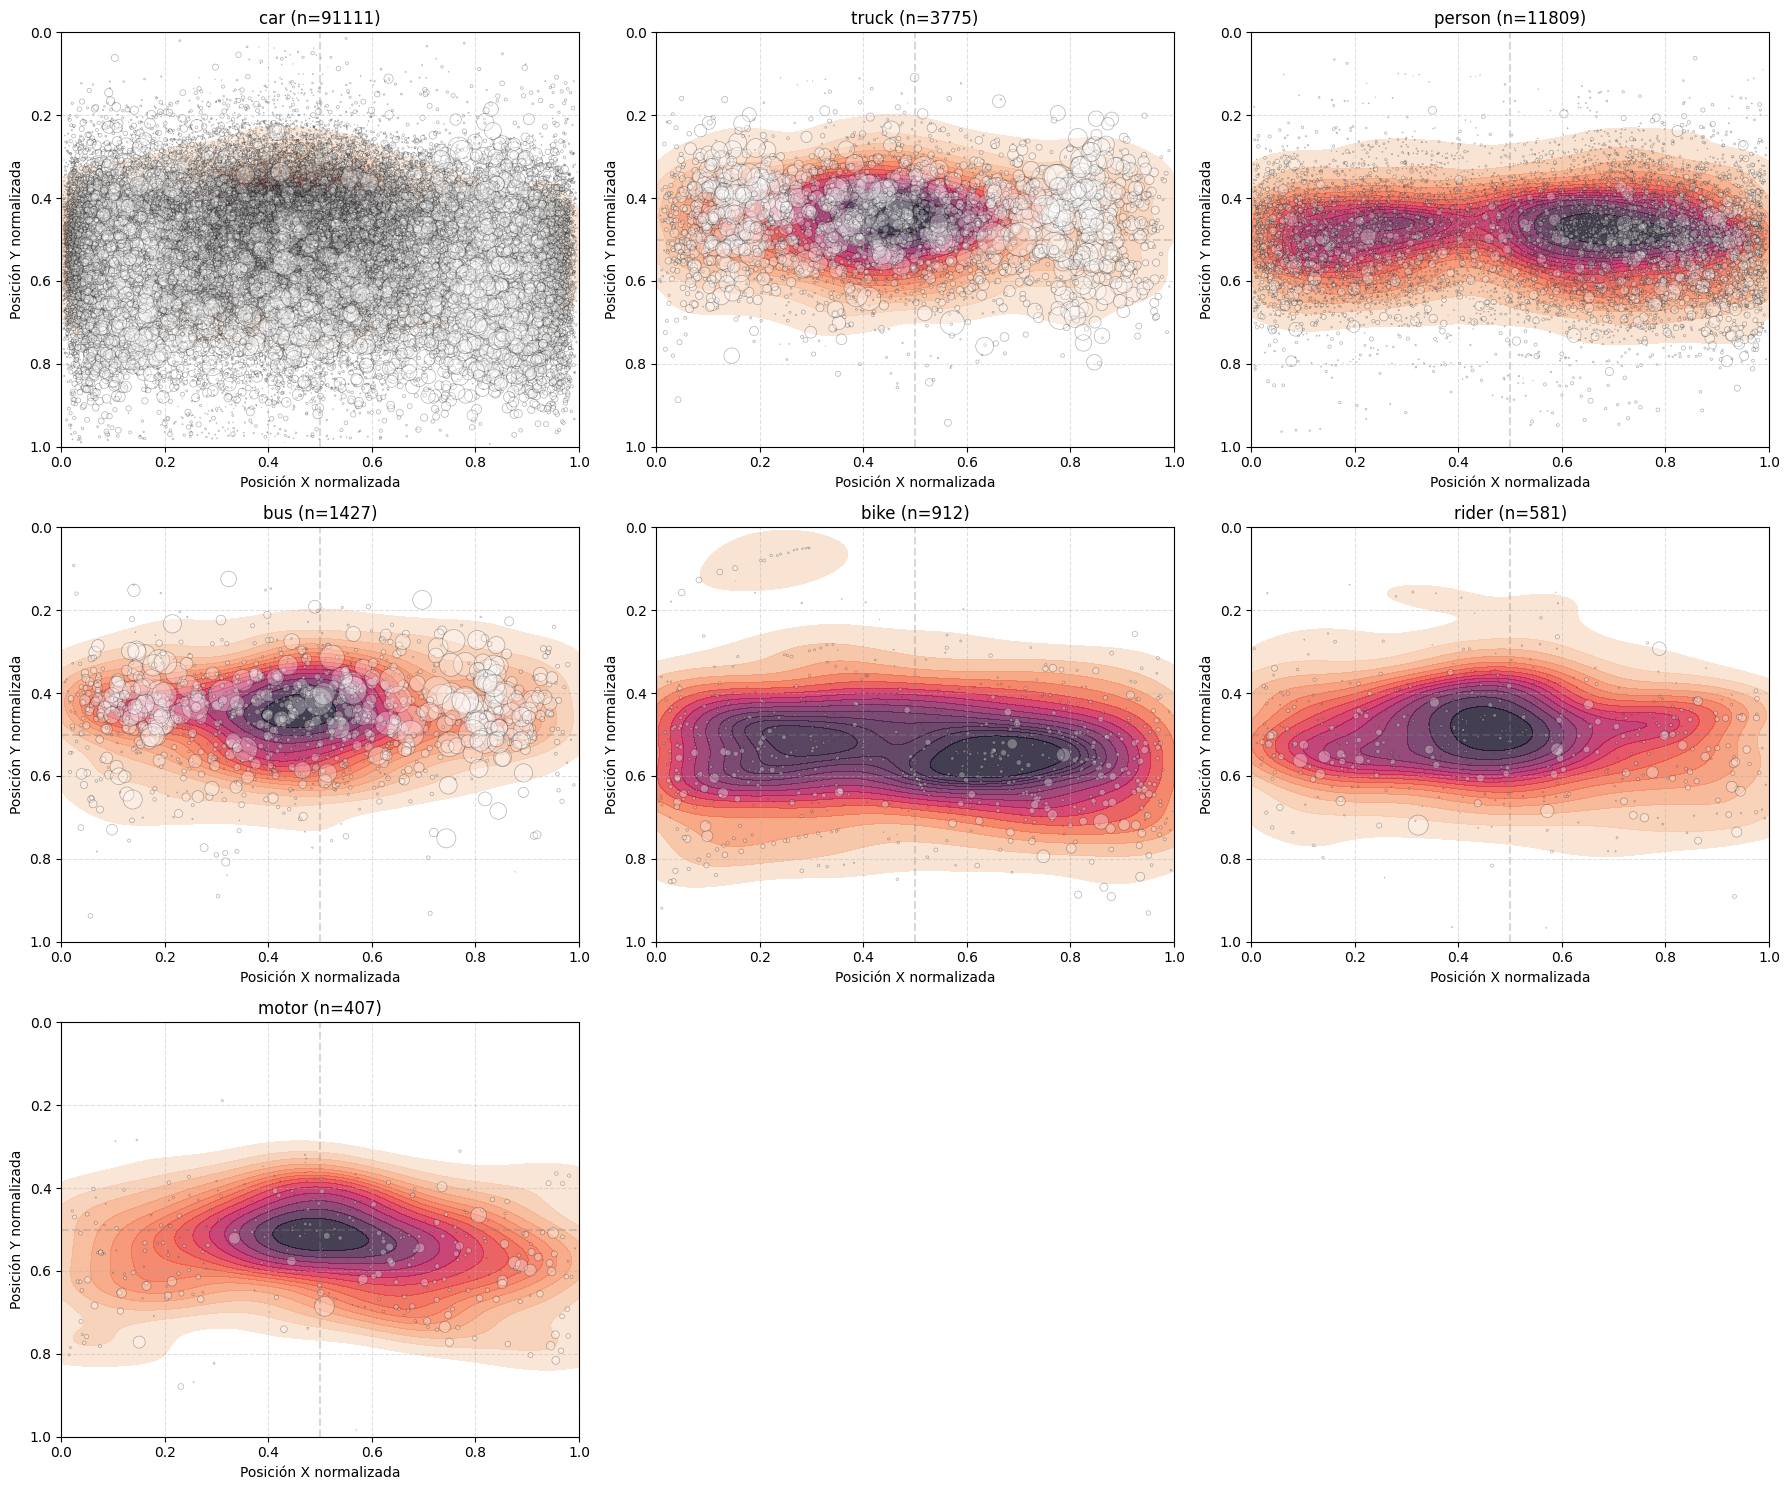

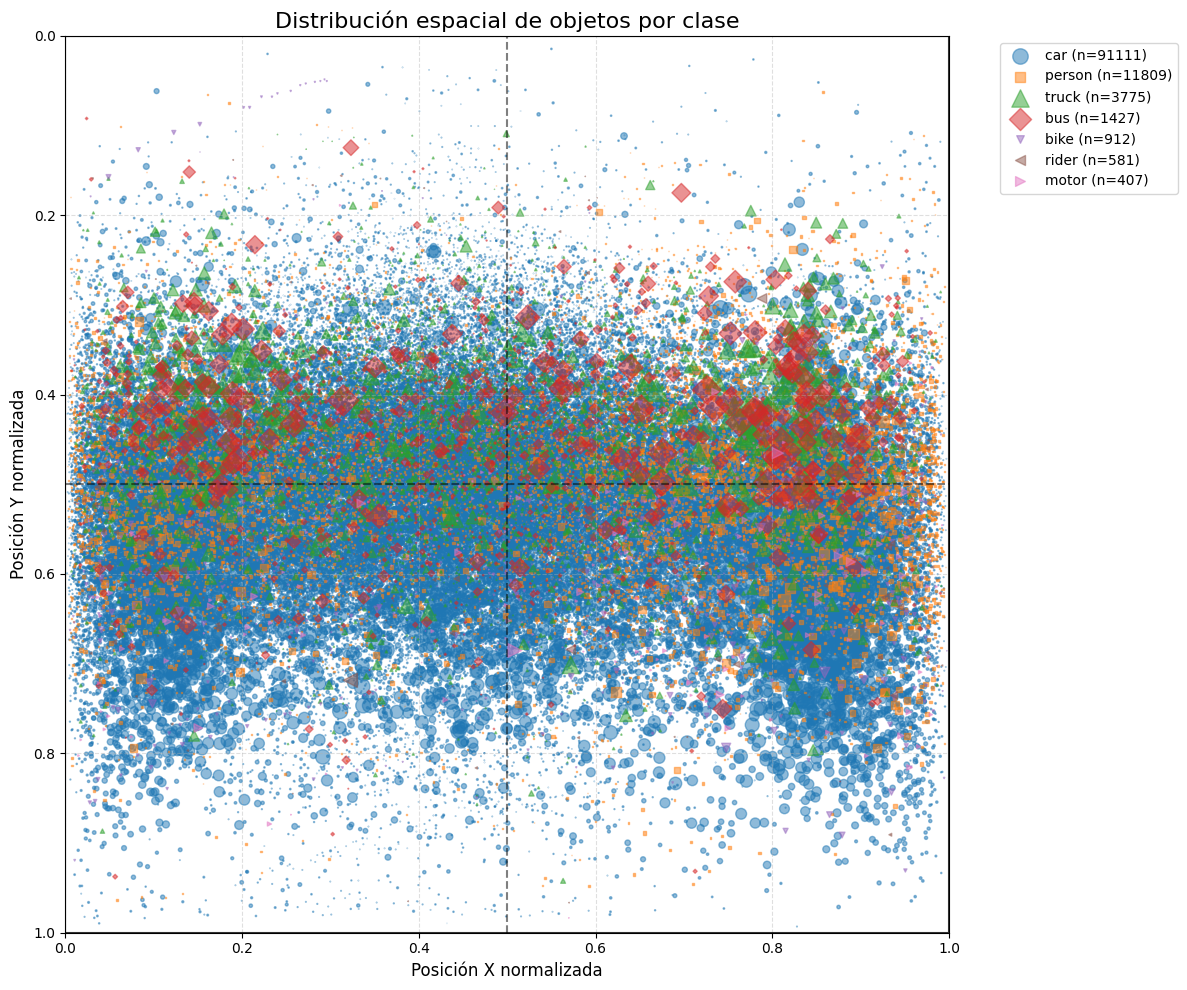


Análisis de sesgo posicional:
car:
  Posición media: X=0.446, Y=0.502
  Variabilidad: σx=0.213, σy=0.111
  Distancia desde el centro: 0.054
  Posible sesgo posicional: Bajo
  Cuadrante preferido: inferior izquierdo

truck:
  Posición media: X=0.451, Y=0.461
  Variabilidad: σx=0.222, σy=0.106
  Distancia desde el centro: 0.063
  Posible sesgo posicional: Bajo
  Cuadrante preferido: superior izquierdo

person:
  Posición media: X=0.524, Y=0.494
  Variabilidad: σx=0.280, σy=0.109
  Distancia desde el centro: 0.025
  Posible sesgo posicional: Bajo
  Cuadrante preferido: superior derecho

bus:
  Posición media: X=0.458, Y=0.456
  Variabilidad: σx=0.227, σy=0.106
  Distancia desde el centro: 0.061
  Posible sesgo posicional: Bajo
  Cuadrante preferido: superior izquierdo

bike:
  Posición media: X=0.486, Y=0.540
  Variabilidad: σx=0.283, σy=0.137
  Distancia desde el centro: 0.042
  Posible sesgo posicional: Bajo
  Cuadrante preferido: inferior izquierdo

rider:
  Posición media: X=0.468, Y

In [56]:
analyze_spatial_distribution()

In [57]:
def analyze_cooccurrence():
    """Analiza qué clases tienden a aparecer juntas en las mismas imágenes"""
    cooccurrence_matrix = np.zeros((len(class_names), len(class_names)))
    class_counts = np.zeros(len(class_names))
    
    for split_dir in ['train', 'valid']:
        dataset_directory = os.path.join(dataset_path, split_dir)
        dataset = sv.DetectionDataset.from_yolo(
            images_directory_path=os.path.join(dataset_directory, 'images'),
            annotations_directory_path=os.path.join(dataset_directory, 'labels'),
            data_yaml_path=os.path.join(dataset_path, 'data.yaml')
        )
        
        # Nuevo método de iteración recomendado por Supervision
        for image_path, image, detections in tqdm(dataset, desc=f"Analizando co-ocurrencia en {split_dir}"):
            # Si no hay detecciones, continuar
            if len(detections) == 0:
                continue
                
            # Obtener clases únicas en esta imagen
            classes_in_image = set(detections.class_id)  # detections.class_id es un array, lo convertimos a set
            
            # Actualizar contadores de clase
            for class_id in classes_in_image:
                class_counts[class_id] += 1
            
            # Actualizar matriz de co-ocurrencia
            for c1 in classes_in_image:
                for c2 in classes_in_image:
                    cooccurrence_matrix[c1, c2] += 1
    
    # Normalizar por frecuencia de clase para obtener probabilidad condicional
    # P(j|i) = P(i,j) / P(i) = co-ocurrencia / frecuencia_i
    normalized_matrix = np.zeros_like(cooccurrence_matrix)
    for i in range(len(class_names)):
        if class_counts[i] > 0:
            normalized_matrix[i, :] = cooccurrence_matrix[i, :] / class_counts[i]
    
    # Visualizar matriz de co-ocurrencia
    plt.figure(figsize=(14, 12))
    
    # Filtrar clases con al menos una ocurrencia
    active_classes = np.where(class_counts > 0)[0]
    filtered_matrix = normalized_matrix[active_classes][:, active_classes]
    active_class_names = [class_names[i] for i in active_classes]
    
    sns.heatmap(
        filtered_matrix,
        xticklabels=active_class_names,
        yticklabels=active_class_names,
        cmap="YlGnBu",
        vmin=0, 
        vmax=min(1.0, filtered_matrix.max() + 0.1),
        annot=True,
        fmt=".2f",
        linewidths=0.5
    )
    
    plt.title("Probabilidad condicional P(columna | fila)", fontsize=14)
    plt.tight_layout()
    plt.show()
    
    return cooccurrence_matrix, normalized_matrix

# Cooccurence analysis

Analizando co-ocurrencia en valid: 100%|██████████| 1960/1960 [00:02<00:00, 825.48it/s]


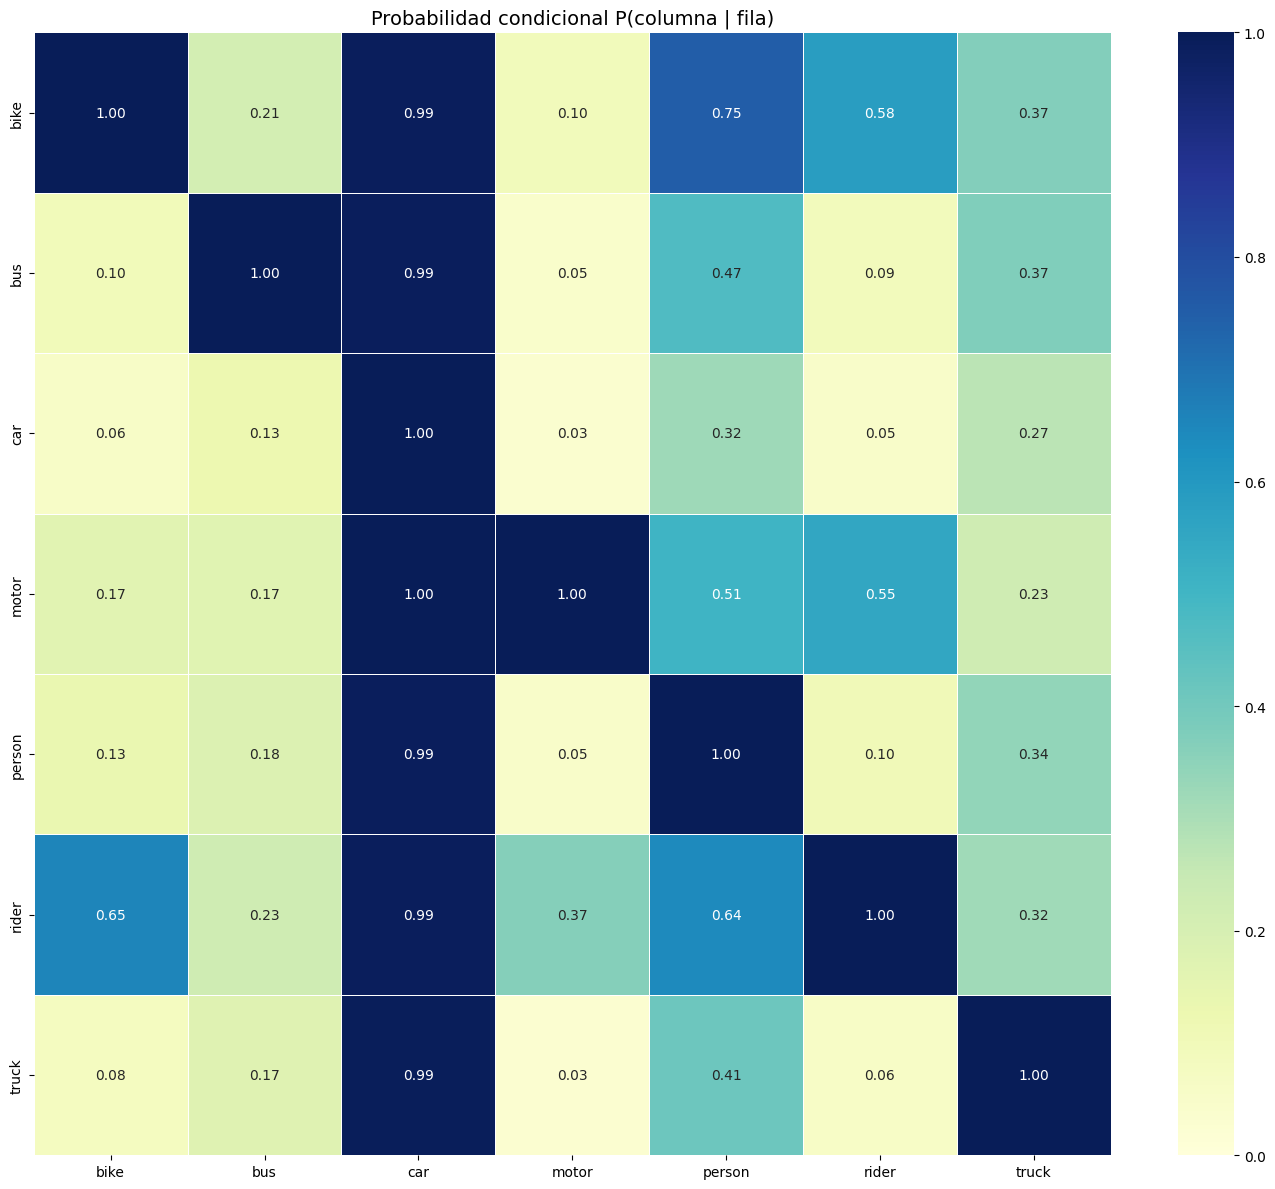

(array([[ 513.,  109.,  508.,   50.,  386.,  299.,  189.],
        [ 109., 1107., 1098.,   51.,  519.,  103.,  415.],
        [ 508., 1098., 8779.,  301., 2840.,  453., 2374.],
        [  50.,   51.,  301.,  302.,  153.,  167.,   68.],
        [ 386.,  519., 2840.,  153., 2869.,  293.,  982.],
        [ 299.,  103.,  453.,  167.,  293.,  457.,  145.],
        [ 189.,  415., 2374.,   68.,  982.,  145., 2389.]]),
 array([[1.        , 0.21247563, 0.99025341, 0.09746589, 0.75243665,
         0.582846  , 0.36842105],
        [0.09846432, 1.        , 0.99186992, 0.04607046, 0.46883469,
         0.09304426, 0.37488708],
        [0.05786536, 0.12507119, 1.        , 0.03428637, 0.32349926,
         0.05160041, 0.27041804],
        [0.16556291, 0.16887417, 0.99668874, 1.        , 0.50662252,
         0.55298013, 0.22516556],
        [0.13454165, 0.18089927, 0.98989195, 0.05332869, 1.        ,
         0.10212618, 0.34227954],
        [0.65426696, 0.22538293, 0.99124726, 0.3654267 , 0.64113786,
 

In [58]:
analyze_cooccurrence()

# Aspect radio analysis

In [59]:
import pandas as pd

In [60]:
def analyze_aspect_ratios():
    """Analiza las proporciones de aspecto de los bounding boxes por clase"""
    aspect_ratios = defaultdict(list)
    
    for split_dir in ['train', 'val']:
        dataset_directory = os.path.join(dataset_path, split_dir)
        dataset = sv.DetectionDataset.from_yolo(
            images_directory_path=os.path.join(dataset_directory, 'images'),
            annotations_directory_path=os.path.join(dataset_directory, 'labels'),
            data_yaml_path=os.path.join(dataset_path, 'data.yaml')
        )
        
        # Nuevo método de iteración recomendado por Supervision
        for image_path, img, detections in tqdm(dataset, desc=f"Analizando proporciones en {split_dir}"):
            if img is None:
                continue
                
            # Si no hay detecciones, continuar
            if len(detections) == 0:
                continue
                
            # Obtener los class_ids y las bounding boxes
            class_ids = detections.class_id
            xyxys = detections.xyxy
            
            # Procesar cada detección
            for class_id, xyxy in zip(class_ids, xyxys):
                x1, y1, x2, y2 = xyxy
                
                width = x2 - x1
                height = y2 - y1
                
                if height > 0:  # Evitar división por cero
                    aspect_ratio = width / height
                    aspect_ratios[class_id].append(aspect_ratio)
    
    # Filtrar clases con suficientes muestras
    valid_classes = {class_id: ratios for class_id, ratios in aspect_ratios.items() 
                   if len(ratios) >= 10}
    
    if not valid_classes:
        print("No hay suficientes datos para el análisis de proporciones.")
        return
    
    # Visualizar distribución de proporciones de aspecto
    plt.figure(figsize=(15, 10))
    
    for class_id, ratios in valid_classes.items():
        sns.kdeplot(ratios, label=f"{class_names[class_id]} (n={len(ratios)})")
    
    plt.axvline(1.0, color='black', linestyle='--', alpha=0.5, label='Cuadrado (1:1)')
    plt.axvline(16/9, color='gray', linestyle=':', alpha=0.5, label='16:9')
    plt.axvline(4/3, color='gray', linestyle='-.', alpha=0.5, label='4:3')
    
    plt.title("Distribución de proporciones de aspecto por clase", fontsize=16)
    plt.xlabel("Proporción de aspecto (ancho/alto)", fontsize=12)
    plt.ylabel("Densidad", fontsize=12)
    plt.legend(title="Clase", fontsize=10, title_fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Calcular y mostrar estadísticas
    stats = {}
    for class_id, ratios in valid_classes.items():
        stats[class_names[class_id]] = {
            'media': np.mean(ratios),
            'mediana': np.median(ratios),
            'min': np.min(ratios),
            'max': np.max(ratios),
            'desv_est': np.std(ratios)
        }
    
    # Mostrar tabla de estadísticas
    stats_df = pd.DataFrame(stats).T
    display(stats_df)
    
    return stats_df

Analizando proporciones en train: 100%|██████████| 6857/6857 [00:07<00:00, 905.67it/s]
Analizando proporciones en val: 0it [00:00, ?it/s]


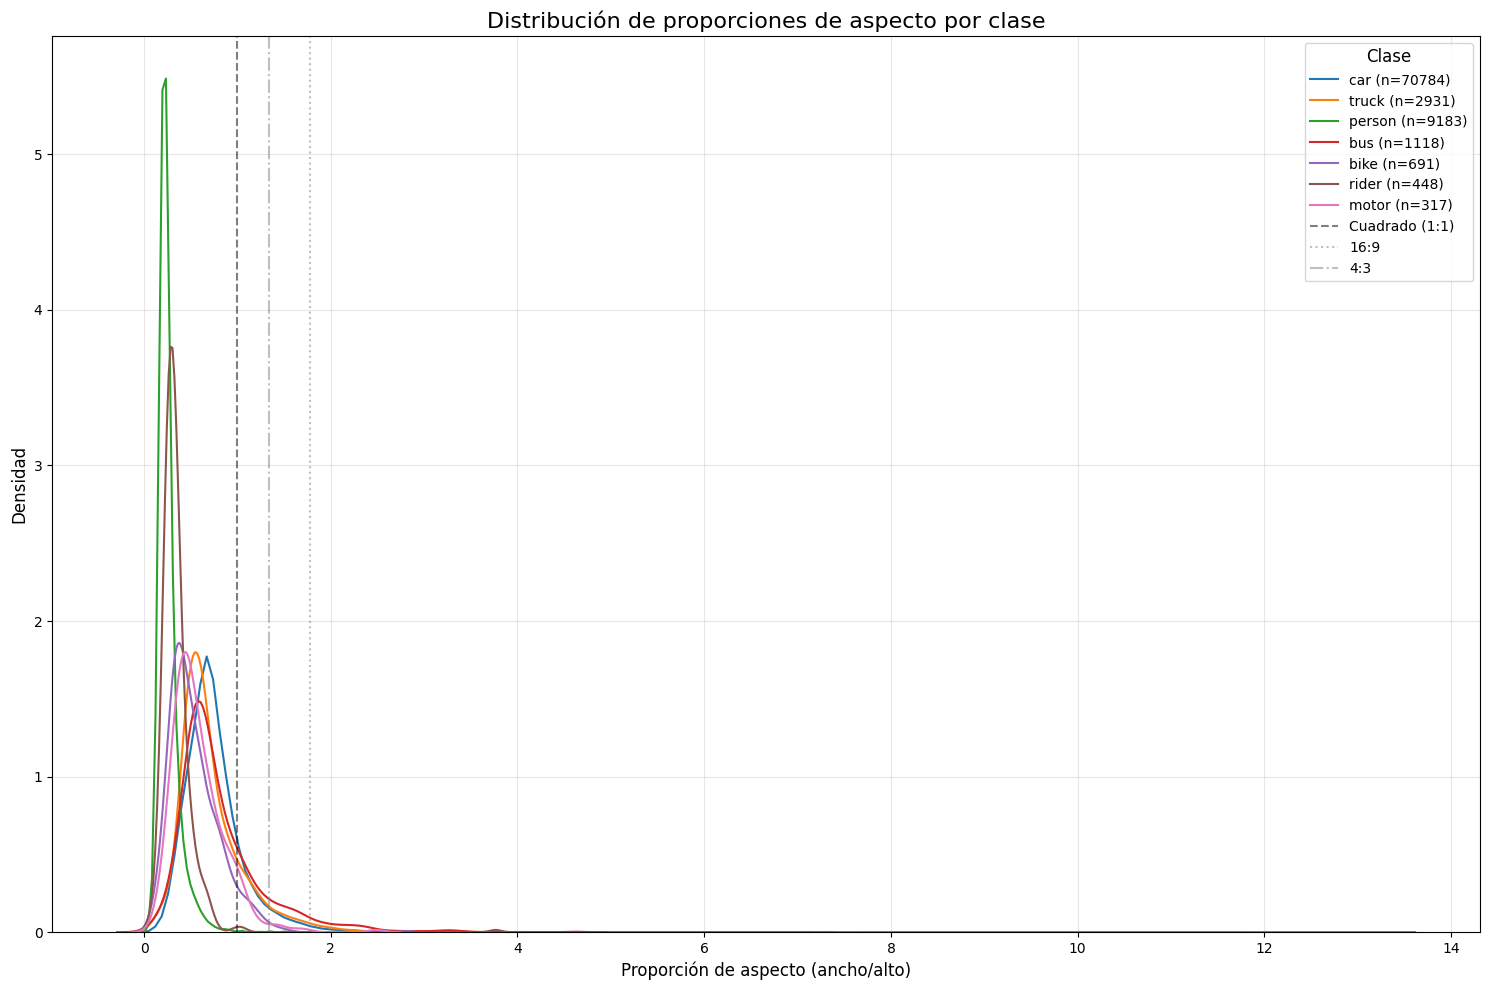

,media,mediana,min,max,desv_est
car,0.754930,0.702413,0.027276,13.500134,0.352759
truck,0.724033,0.625000,0.040178,4.017866,0.380183
person,0.259684,0.232337,0.050000,7.312365,0.157398
bus,0.811145,0.664906,0.057129,4.608867,0.469169
bike,0.536348,0.473684,0.052437,2.812496,0.271432
rider,0.344343,0.309375,0.056882,3.764423,0.205156
motor,0.579823,0.511364,0.147810,2.481617,0.280126


,media,mediana,min,max,desv_est
car,0.754930,0.702413,0.027276,13.500134,0.352759
truck,0.724033,0.625000,0.040178,4.017866,0.380183
person,0.259684,0.232337,0.050000,7.312365,0.157398
bus,0.811145,0.664906,0.057129,4.608867,0.469169
bike,0.536348,0.473684,0.052437,2.812496,0.271432
rider,0.344343,0.309375,0.056882,3.764423,0.205156
motor,0.579823,0.511364,0.147810,2.481617,0.280126


In [61]:
analyze_aspect_ratios()

In [62]:
def analyze_object_sizes():
    """Analiza la distribución de tamaños de objetos por clase"""
    relative_sizes = defaultdict(list)
    absolute_sizes = defaultdict(list)
    
    for split_dir in ['train', 'valid']:
        dataset_directory = os.path.join(dataset_path, split_dir)
        dataset = sv.DetectionDataset.from_yolo(
            images_directory_path=os.path.join(dataset_directory, 'images'),
            annotations_directory_path=os.path.join(dataset_directory, 'labels'),
            data_yaml_path=os.path.join(dataset_path, 'data.yaml')
        )
        
        # Nuevo método de iteración recomendado por Supervision
        for image_path, img, detections in tqdm(dataset, desc=f"Analizando tamaños en {split_dir}"):
            if img is None:
                continue
                
            # Si no hay detecciones, continuar
            if len(detections) == 0:
                continue
                
            img_height, img_width = img.shape[:2]
            img_area = img_height * img_width
            
            # Obtener los class_ids y las bounding boxes
            class_ids = detections.class_id
            xyxys = detections.xyxy
            
            # Procesar cada detección
            for class_id, xyxy in zip(class_ids, xyxys):
                x1, y1, x2, y2 = xyxy
                
                # Calcular área del bounding box
                bbox_width = x2 - x1
                bbox_height = y2 - y1
                bbox_area = bbox_width * bbox_height
                
                # Tamaño relativo (porcentaje de la imagen)
                rel_size = bbox_area / img_area
                
                relative_sizes[class_id].append(rel_size)
                absolute_sizes[class_id].append(bbox_area)
    
    # Filtrar clases con suficientes muestras
    valid_classes = {class_id: sizes for class_id, sizes in relative_sizes.items() 
                   if len(sizes) >= 10}
    
    if not valid_classes:
        print("No hay suficientes datos para el análisis de tamaños.")
        return
    
    # Visualizar distribución de tamaños relativos
    plt.figure(figsize=(15, 10))
    
    # Usar boxplot para mejor visualización de la distribución
    boxplot_data = [valid_classes[class_id] for class_id in sorted(valid_classes.keys())]
    class_labels = [class_names[class_id] for class_id in sorted(valid_classes.keys())]
    
    # Convertir a porcentaje para mejor legibilidad
    boxplot_data_percent = [np.array(sizes) * 100 for sizes in boxplot_data]
    
    plt.boxplot(boxplot_data_percent, labels=class_labels, vert=False, patch_artist=True)
    plt.xscale('log')  # Escala logarítmica para mejor visualización
    plt.xlabel("Tamaño relativo (% del área de la imagen)", fontsize=12)
    plt.ylabel("Clase", fontsize=12)
    plt.title("Distribución de tamaños relativos de objetos por clase", fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Calcular y mostrar estadísticas
    stats = {}
    for class_id, sizes in valid_classes.items():
        sizes_percent = np.array(sizes) * 100  # Convertir a porcentaje
        stats[class_names[class_id]] = {
            'media (%)': np.mean(sizes_percent),
            'mediana (%)': np.median(sizes_percent),
            'min (%)': np.min(sizes_percent),
            'max (%)': np.max(sizes_percent),
            'desv_est (%)': np.std(sizes_percent)
        }
    
    # Mostrar tabla de estadísticas
    stats_df = pd.DataFrame(stats).T
    display(stats_df)
    
    return stats_df, relative_sizes, absolute_sizes

Analizando tamaños en valid: 100%|██████████| 1960/1960 [00:02<00:00, 834.22it/s]


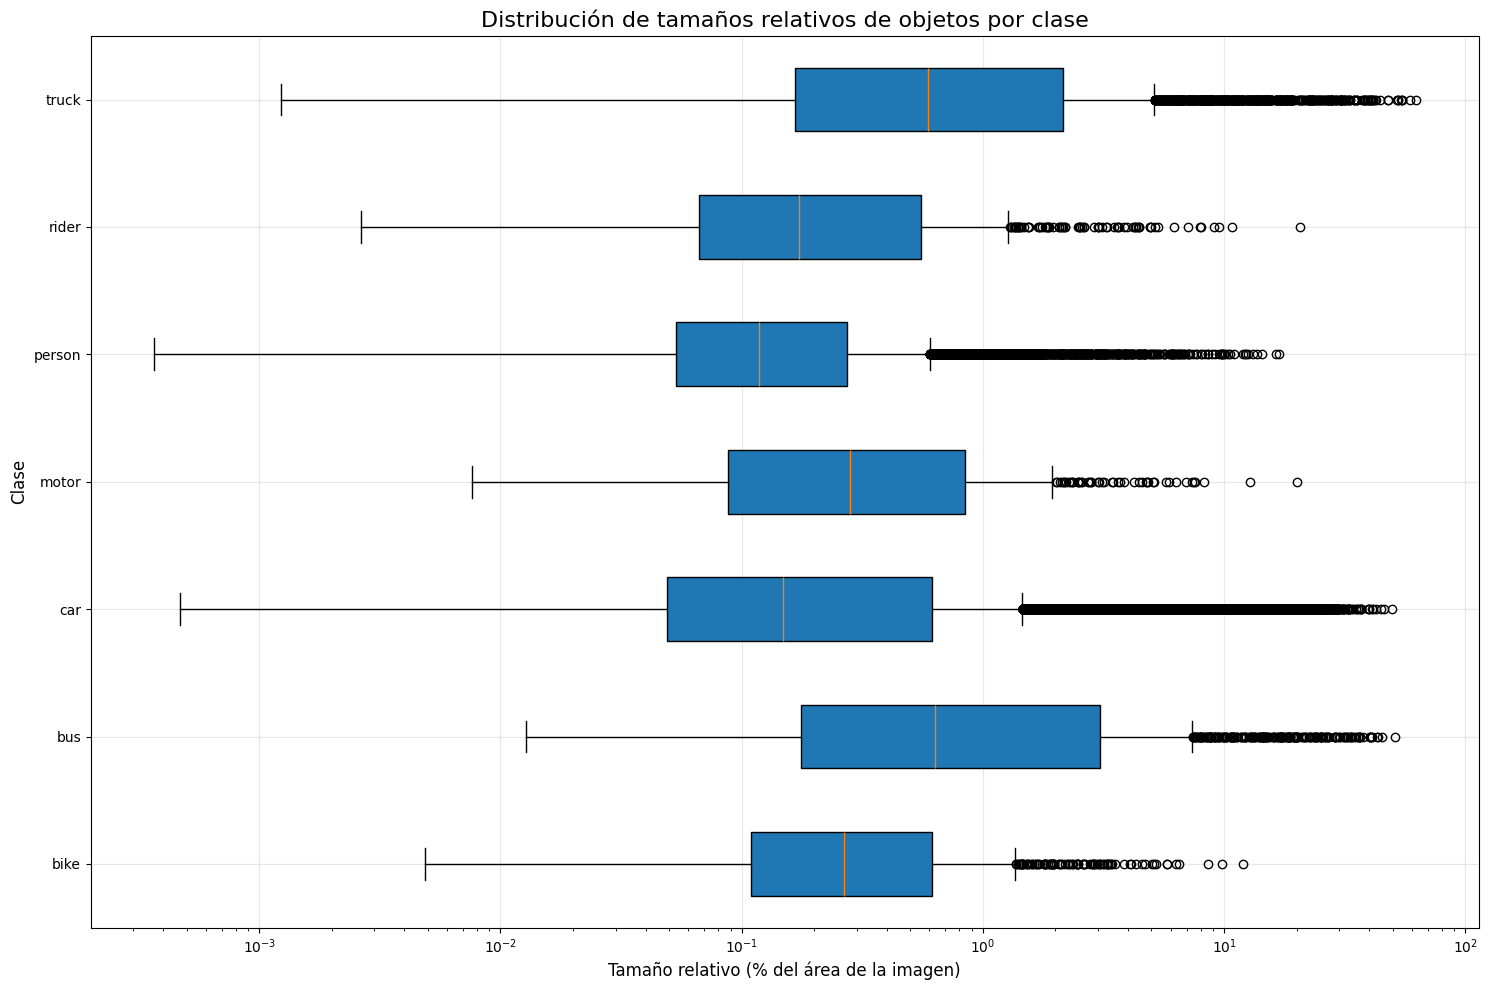

,media (%),mediana (%),min (%),max (%),desv_est (%)
car,1.023226,0.148263,0.000468,49.447987,2.715251
truck,2.926353,0.593077,0.001226,62.281361,6.411775
person,0.312664,0.118132,0.000366,16.844635,0.782834
bus,3.615603,0.631989,0.012779,51.019375,7.178477
bike,0.588000,0.265766,0.004863,11.959070,1.001628
rider,0.653214,0.172312,0.002653,20.731905,1.502246
motor,0.848354,0.282209,0.007652,20.084850,1.704398


(        media (%)  mediana (%)   min (%)    max (%)  desv_est (%)
 car      1.023226     0.148263  0.000468  49.447987      2.715251
 truck    2.926353     0.593077  0.001226  62.281361      6.411775
 person   0.312664     0.118132  0.000366  16.844635      0.782834
 bus      3.615603     0.631989  0.012779  51.019375      7.178477
 bike     0.588000     0.265766  0.004863  11.959070      1.001628
 rider    0.653214     0.172312  0.002653  20.731905      1.502246
 motor    0.848354     0.282209  0.007652  20.084850      1.704398,
 defaultdict(list,
             {2: [0.00039019722491502763,
               0.001072062775492668,
               0.0033107739686965942,
               0.012249864339828491,
               0.01950992465019226,
               0.06585128784179688,
               0.0005320893600583076,
               0.00040990684181451797,
               0.0003586675226688385,
               0.0031728246808052064,
               0.001135120913386345,
               0.00368914961

In [63]:
analyze_object_sizes()